In [1]:
print("Module 2 - Analytics Pipeline")
print("=" * 50)

!pip install -q seaborn scikit-learn imbalanced-learn joblib pandas matplotlib

Module 2 - Analytics Pipeline


In [2]:
import os

os.makedirs("analytics", exist_ok=True)
os.makedirs("analytics/charts", exist_ok=True)

print("analytics folder created successfully!")

analytics folder created successfully!


In [3]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.to_csv("analytics/titanic.csv", index=False)

print("Offline fallback saved:")
print("analytics/titanic.csv")

Dataset loaded successfully!
Shape: (891, 15)
Offline fallback saved:
analytics/titanic.csv


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows: 891
Columns: 15

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe())

print("\n" + "=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})
missing_table = missing_table[
    missing_table["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_table)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DESCRIPTIVE STATISTICS


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



DATASET SHAPE
Rows: 891
Columns: 15

MISSING VALUES


,Missing Count,Missing Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [6]:
missing_table.to_csv(
    "analytics/missing_values_report.csv"
)

print("Missing-value report saved successfully!")

Missing-value report saved successfully!


In [7]:
print("=" * 60)
print("MISSING-VALUE CLEANING STRATEGY")
print("=" * 60)

for column in missing_table.index:
    percentage = missing_table.loc[
        column, "Missing Percentage"
    ]

    if percentage < 5:
        strategy = "Drop rows with missing values"

    elif percentage <= 30:
        strategy = "Impute missing values"

    else:
        strategy = (
            "High missingness - evaluate column/category "
            "handling separately"
        )

    print(
        f"{column}: {percentage:.2f}% missing -> {strategy}"
    )

MISSING-VALUE CLEANING STRATEGY
deck: 77.22% missing -> High missingness - evaluate column/category handling separately
age: 19.87% missing -> Impute missing values
embarked: 0.22% missing -> Drop rows with missing values
embark_town: 0.22% missing -> Drop rows with missing values


In [8]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

df_clean = df_clean.drop(columns=["deck"])

print("After dropping deck:", df_clean.shape)

df_clean = df_clean.dropna(
    subset=["embarked", "embark_town"]
)

print(
    "After dropping missing embarked rows:",
    df_clean.shape
)


age_median = df_clean["age"].median()

df_clean["age"] = df_clean["age"].fillna(age_median)

print("Age median used for imputation:", age_median)


print("\nRemaining missing values:")

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("No missing values remain.")
else:
    print(remaining_missing)

print("\nFinal cleaned dataset shape:")
print(df_clean.shape)

print("\nCleaning completed successfully!")

Original shape: (891, 15)
After dropping deck: (891, 14)
After dropping missing embarked rows: (889, 14)
Age median used for imputation: 28.0

Remaining missing values:
No missing values remain.

Final cleaned dataset shape:
(889, 14)

Cleaning completed successfully!


In [9]:
print("=" * 60)
print("CLEANED DATASET VALIDATION")
print("=" * 60)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nFirst 5 cleaned rows:")
display(df_clean.head())

print("\nCleaned dataset shape:")
print(df_clean.shape)

CLEANED DATASET VALIDATION

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

First 5 cleaned rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True



Cleaned dataset shape:
(889, 14)


In [10]:
df_clean.to_csv(
    "analytics/titanic_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("analytics/titanic_cleaned.csv")

Cleaned dataset saved successfully!
analytics/titanic_cleaned.csv


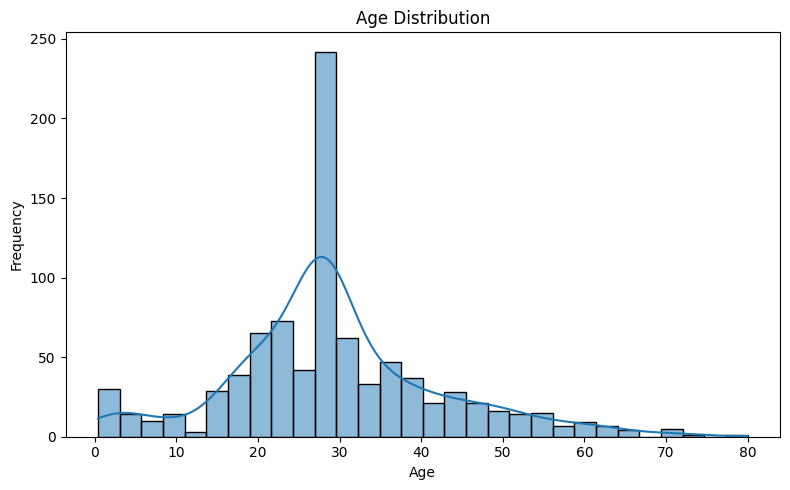

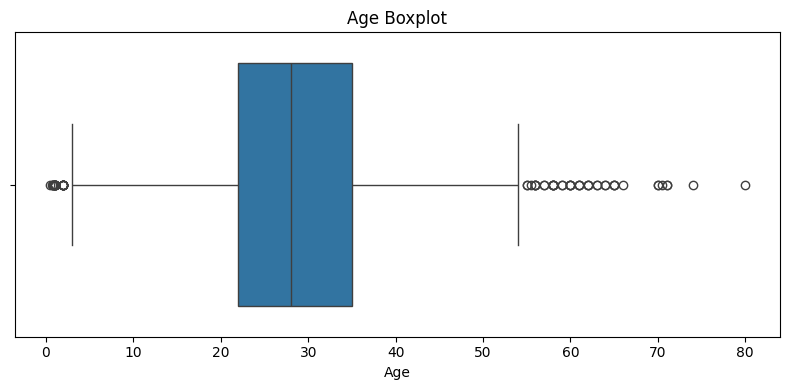

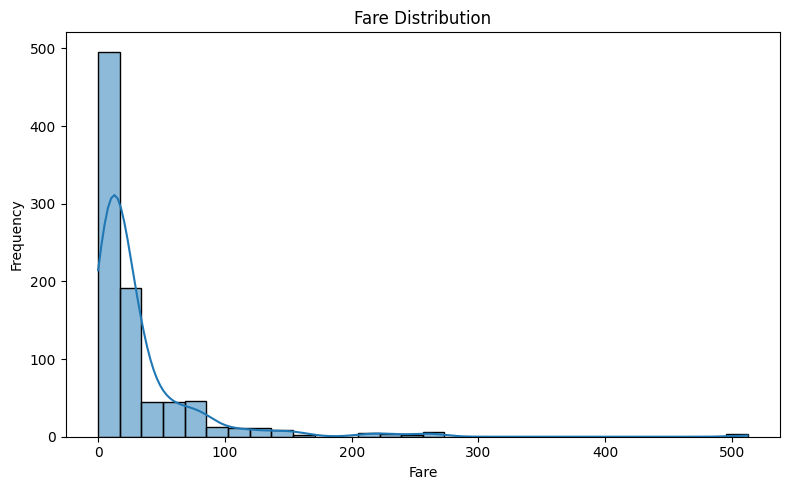

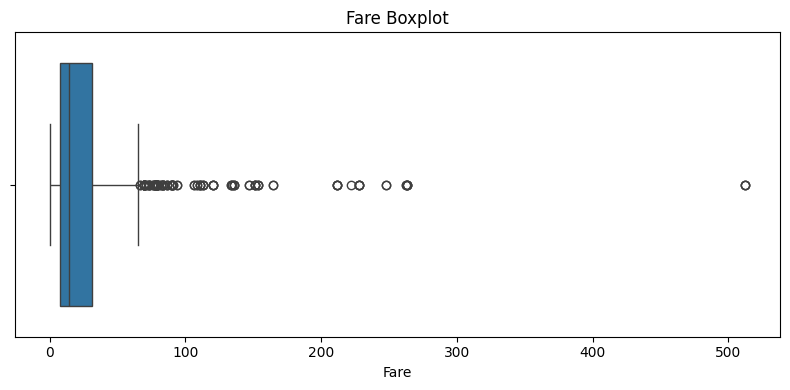

All four univariate charts created successfully!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("analytics/charts", exist_ok=True)

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "analytics/charts/age_histogram.png",
    dpi=300
)

plt.show()


plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["age"]
)

plt.title("Age Boxplot")
plt.xlabel("Age")
plt.tight_layout()

plt.savefig(
    "analytics/charts/age_boxplot.png",
    dpi=300
)

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "analytics/charts/fare_histogram.png",
    dpi=300
)

plt.show()

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["fare"]
)

plt.title("Fare Boxplot")
plt.xlabel("Fare")
plt.tight_layout()

plt.savefig(
    "analytics/charts/fare_boxplot.png",
    dpi=300
)

plt.show()

print("All four univariate charts created successfully!")

In [12]:
def calculate_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }


age_outliers = calculate_iqr_outliers(
    df_clean,
    "age"
)

fare_outliers = calculate_iqr_outliers(
    df_clean,
    "fare"
)

print("=" * 60)
print("AGE IQR OUTLIER ANALYSIS")
print("=" * 60)

for key, value in age_outliers.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float)
          else f"{key}: {value}")

print("\n" + "=" * 60)
print("FARE IQR OUTLIER ANALYSIS")
print("=" * 60)

for key, value in fare_outliers.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float)
          else f"{key}: {value}")

AGE IQR OUTLIER ANALYSIS
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower Bound: 2.50
Upper Bound: 54.50
Outlier Count: 65

FARE IQR OUTLIER ANALYSIS
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower Bound: -26.76
Upper Bound: 65.66
Outlier Count: 114


In [13]:
outlier_results = pd.DataFrame([
    {
        "Variable": "Age",
        **age_outliers
    },
    {
        "Variable": "Fare",
        **fare_outliers
    }
])

display(outlier_results)

outlier_results.to_csv(
    "analytics/iqr_outlier_results.csv",
    index=False
)

print("IQR outlier results saved successfully!")

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,22.0000,35.0,13.0000,2.5000,54.5000,65
1,Fare,7.8958,31.0,23.1042,-26.7605,65.6563,114


IQR outlier results saved successfully!


In [14]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
fare_skewness = df_clean["fare"].skew()

print("=" * 60)
print("FARE STATISTICS")
print("=" * 60)

print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")
print(f"Skewness: {fare_skewness:.4f}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

if fare_skewness > 0:
    interpretation = (
        "Fare is positively/right skewed. "
        "A small number of passengers paid very high fares, "
        "which pulls the mean upward."
    )
elif fare_skewness < 0:
    interpretation = (
        "Fare is negatively/left skewed. "
        "The distribution has a longer tail toward lower fares."
    )
else:
    interpretation = (
        "Fare is approximately symmetric."
    )

print(interpretation)

FARE STATISTICS
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500
Skewness: 4.8014

INTERPRETATION
Fare is positively/right skewed. A small number of passengers paid very high fares, which pulls the mean upward.


In [15]:
fare_statistics = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Skewness"
    ],
    "Value": [
        fare_mean,
        fare_median,
        fare_mode,
        fare_skewness
    ]
})

display(fare_statistics)

fare_statistics.to_csv(
    "analytics/fare_statistics.csv",
    index=False
)

print("Fare statistics saved successfully!")

,Statistic,Value
0,Mean,32.096681
1,Median,14.454200
2,Mode,8.050000
3,Skewness,4.801440


Fare statistics saved successfully!


In [16]:
survival_by_sex = (
    df_clean
    .groupby("sex")["survived"]
    .mean()
    .reset_index()
)

survival_by_sex["survival_rate_percent"] = (
    survival_by_sex["survived"] * 100
)

print("=" * 60)
print("SURVIVAL RATE BY SEX")
print("=" * 60)

display(survival_by_sex)

SURVIVAL RATE BY SEX


,sex,survived,survival_rate_percent
0,female,0.740385,74.038462
1,male,0.188908,18.890815


In [17]:
survival_by_class = (
    df_clean
    .groupby("pclass")["survived"]
    .mean()
    .reset_index()
)

survival_by_class["survival_rate_percent"] = (
    survival_by_class["survived"] * 100
)

print("=" * 60)
print("SURVIVAL RATE BY PASSENGER CLASS")
print("=" * 60)

display(survival_by_class)

SURVIVAL RATE BY PASSENGER CLASS


,pclass,survived,survival_rate_percent
0,1,0.626168,62.616822
1,2,0.472826,47.282609
2,3,0.242363,24.236253


In [19]:
survival_by_sex = (
    df_clean
    .groupby("sex")["survived"]
    .mean()
    .reset_index()
)

survival_by_sex["survival_rate_percent"] = (
    survival_by_sex["survived"] * 100
)


survival_by_class = (
    df_clean
    .groupby("pclass")["survived"]
    .mean()
    .reset_index()
)

survival_by_class["survival_rate_percent"] = (
    survival_by_class["survived"] * 100
)


survival_sex_class = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

survival_sex_class["survival_rate_percent"] = (
    survival_sex_class["survived"] * 100
)


print("=" * 60)
print("SURVIVAL RATE BY SEX")
print("=" * 60)
display(survival_by_sex)

print("=" * 60)
print("SURVIVAL RATE BY CLASS")
print("=" * 60)
display(survival_by_class)

print("=" * 60)
print("SURVIVAL RATE BY SEX AND CLASS")
print("=" * 60)
display(survival_sex_class)

SURVIVAL RATE BY SEX


,sex,survived,survival_rate_percent
0,female,0.740385,74.038462
1,male,0.188908,18.890815


SURVIVAL RATE BY CLASS


,pclass,survived,survival_rate_percent
0,1,0.626168,62.616822
1,2,0.472826,47.282609
2,3,0.242363,24.236253


SURVIVAL RATE BY SEX AND CLASS


,sex,pclass,survived,survival_rate_percent
0,female,1,0.967391,96.739130
1,female,2,0.921053,92.105263
2,female,3,0.500000,50.000000
3,male,1,0.368852,36.885246
4,male,2,0.157407,15.740741
5,male,3,0.135447,13.544669


In [20]:
survival_by_sex.to_csv(
    "analytics/survival_by_sex.csv",
    index=False
)

survival_by_class.to_csv(
    "analytics/survival_by_class.csv",
    index=False
)

survival_sex_class.to_csv(
    "analytics/survival_by_sex_class.csv",
    index=False
)

print("All survival analysis results saved successfully!")

All survival analysis results saved successfully!


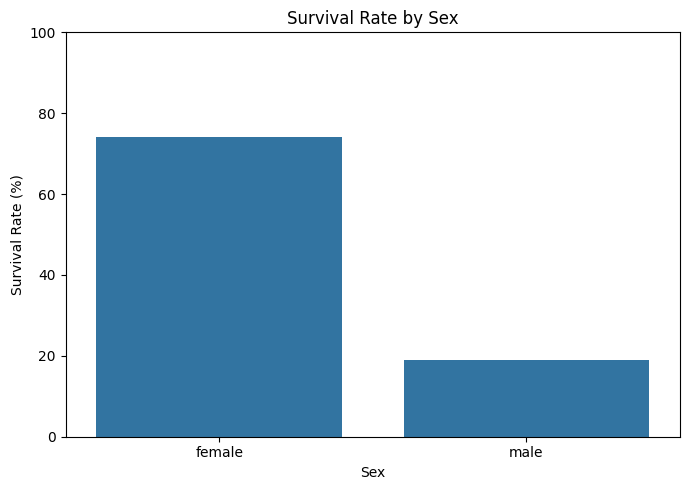

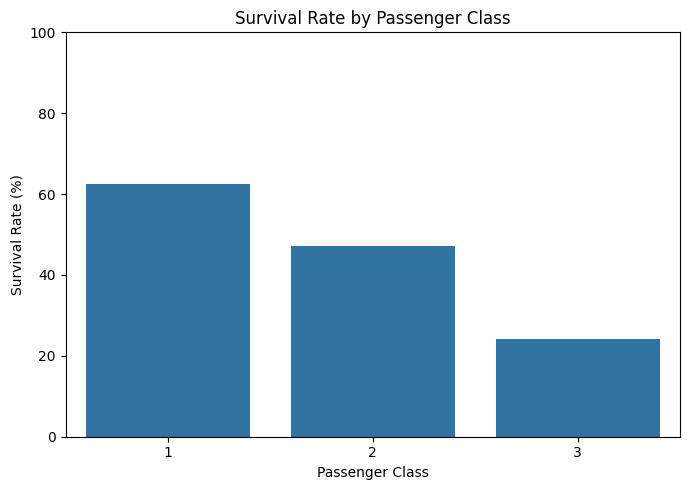

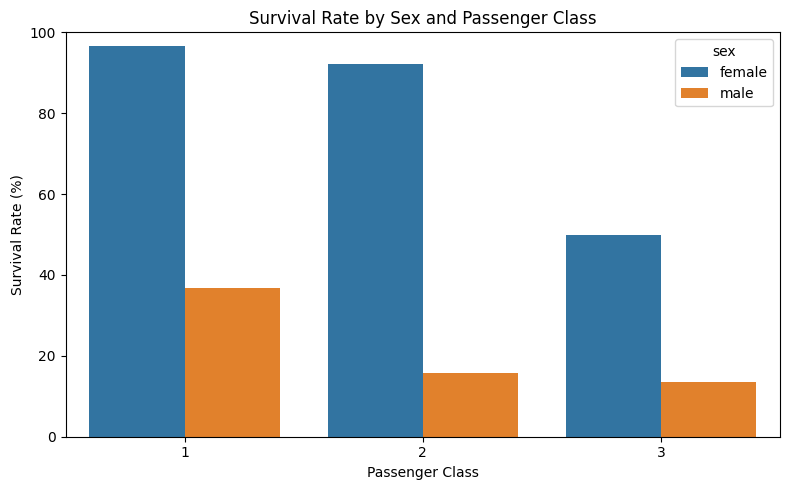

All survival charts created successfully!


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_sex,
    x="sex",
    y="survival_rate_percent"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(
    "analytics/charts/survival_by_sex.png",
    dpi=300
)

plt.show()



plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_class,
    x="pclass",
    y="survival_rate_percent"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(
    "analytics/charts/survival_by_class.png",
    dpi=300
)

plt.show()



plt.figure(figsize=(8, 5))

sns.barplot(
    data=survival_sex_class,
    x="pclass",
    y="survival_rate_percent",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig(
    "analytics/charts/survival_sex_class.png",
    dpi=300
)

plt.show()

print("All survival charts created successfully!")

## Bivariate Analysis Interpretation

### Survival by Sex

The survival rate was substantially higher for female passengers than male passengers. Approximately 74.04% of female passengers survived, compared with only 18.89% of male passengers. This indicates a strong association between sex and survival in the Titanic dataset.

### Survival by Passenger Class

Passenger class also shows a clear relationship with survival. First-class passengers had a survival rate of approximately 62.62%, followed by second-class passengers at 47.29% and third-class passengers at 24.24%. Therefore, passengers in higher classes generally had better survival outcomes.

### Survival by Sex and Passenger Class

The combined analysis provides a stronger multivariate view. Female first-class passengers had the highest survival rate at approximately 96.74%, while male third-class passengers had the lowest survival rate at approximately 13.54%.

Overall, the analysis suggests that both sex and passenger class were important factors associated with Titanic survival.

In [22]:
import os

print("Charts currently saved:")
print("=" * 50)

for file in sorted(os.listdir("analytics/charts")):
    print(file)

Charts currently saved:
age_boxplot.png
age_histogram.png
fare_boxplot.png
fare_histogram.png
survival_by_class.png
survival_by_sex.png
survival_sex_class.png


In [23]:
correlation_columns = [
    "survived",
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

display(correlation_matrix)

CORRELATION MATRIX


,survived,age,sibsp,parch,fare,pclass
survived,1.000000,-0.069822,-0.034040,0.083151,0.255290,-0.335549
age,-0.069822,1.000000,-0.232543,-0.171485,0.093707,-0.336512
sibsp,-0.034040,-0.232543,1.000000,0.414542,0.160887,0.081656
parch,0.083151,-0.171485,0.414542,1.000000,0.217532,0.016824
fare,0.255290,0.093707,0.160887,0.217532,1.000000,-0.548193
pclass,-0.335549,-0.336512,0.081656,0.016824,-0.548193,1.000000


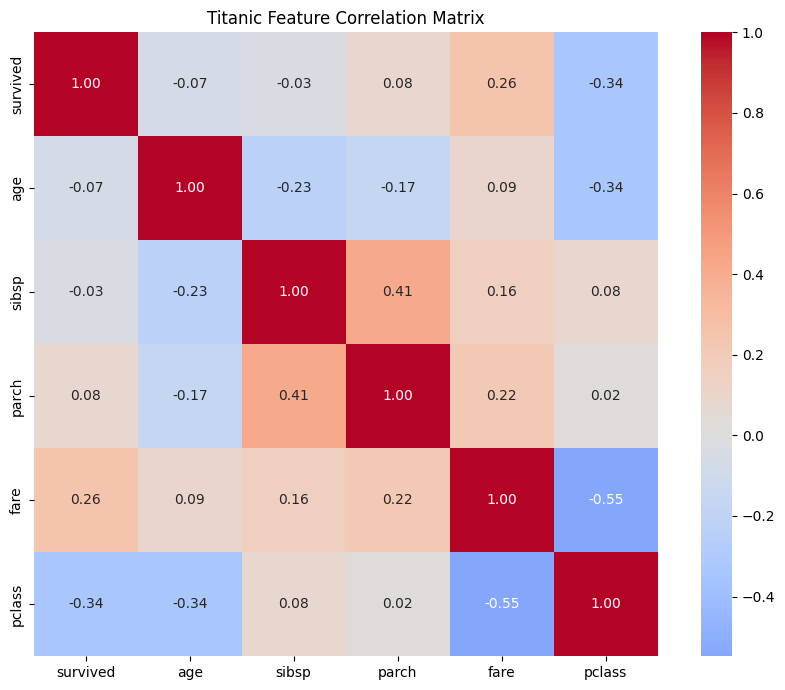

Correlation heatmap saved successfully!


In [24]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Titanic Feature Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "analytics/charts/correlation_heatmap.png",
    dpi=300
)

plt.show()

print("Correlation heatmap saved successfully!")

In [25]:
correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        variable_1 = correlation_matrix.columns[i]
        variable_2 = correlation_matrix.columns[j]

        correlation_value = correlation_matrix.iloc[i, j]

        correlation_pairs.append({
            "Variable 1": variable_1,
            "Variable 2": variable_2,
            "Correlation": correlation_value,
            "Absolute Correlation": abs(correlation_value)
        })

correlation_pairs_df = pd.DataFrame(
    correlation_pairs
)

strongest_correlations = (
    correlation_pairs_df
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .head(2)
    .reset_index(drop=True)
)

print("=" * 60)
print("TWO STRONGEST CORRELATIONS")
print("=" * 60)

display(strongest_correlations)

TWO STRONGEST CORRELATIONS


,Variable 1,Variable 2,Correlation,Absolute Correlation
0,fare,pclass,-0.548193,0.548193
1,sibsp,parch,0.414542,0.414542


In [26]:
correlation_matrix.to_csv(
    "analytics/correlation_matrix.csv"
)

strongest_correlations.to_csv(
    "analytics/strongest_correlations.csv",
    index=False
)

print("Correlation results saved successfully!")

Correlation results saved successfully!


## Correlation Analysis Interpretation

The correlation matrix was created using the six required variables: survived, age, sibsp, parch, fare, and pclass.

### 1. Fare and Passenger Class

The strongest absolute correlation was between fare and passenger class, with a correlation coefficient of approximately -0.548. This is a moderate negative relationship. Since passenger class is represented numerically as 1st, 2nd, and 3rd class, a higher class number represents a lower passenger class. Therefore, passengers in higher-ranked classes generally paid higher fares, while passengers in lower-ranked classes generally paid lower fares.

### 2. SibSp and Parch

The second strongest absolute correlation was between SibSp and Parch, with a correlation coefficient of approximately +0.415. This is a moderate positive relationship. It suggests that passengers traveling with more siblings or spouses also tended to travel with more parents or children, indicating that family groups often traveled together.

Overall, the correlation analysis shows meaningful relationships among passenger class, fare, and family-related variables, while correlation alone does not establish causation.

In [27]:
print("Correlation analysis files:")

print("✓ correlation_matrix.csv")
print("✓ strongest_correlations.csv")
print("✓ correlation_heatmap.png")

print("\nCorrelation analysis completed successfully!")

Correlation analysis files:
✓ correlation_matrix.csv
✓ strongest_correlations.csv
✓ correlation_heatmap.png

Correlation analysis completed successfully!


In [28]:
multivariate_summary = (
    df_clean
    .groupby(["sex", "pclass"])
    .agg(
        survival_rate=("survived", "mean"),
        average_age=("age", "mean"),
        average_fare=("fare", "mean"),
        passenger_count=("survived", "count")
    )
    .reset_index()
)

multivariate_summary["survival_rate_percent"] = (
    multivariate_summary["survival_rate"] * 100
)

print("=" * 70)
print("MULTIVARIATE SUMMARY: SEX + CLASS + AGE + FARE + SURVIVAL")
print("=" * 70)

display(multivariate_summary)

MULTIVARIATE SUMMARY: SEX + CLASS + AGE + FARE + SURVIVAL


,sex,pclass,survival_rate,average_age,average_fare,passenger_count,survival_rate_percent
0,female,1,0.967391,33.630435,106.693750,92,96.739130
1,female,2,0.921053,28.703947,21.970121,76,92.105263
2,female,3,0.500000,23.572917,16.118810,144,50.000000
3,male,1,0.368852,38.995246,67.226127,122,36.885246
4,male,2,0.157407,30.512315,19.741782,108,15.740741
5,male,3,0.135447,26.911873,12.661633,347,13.544669


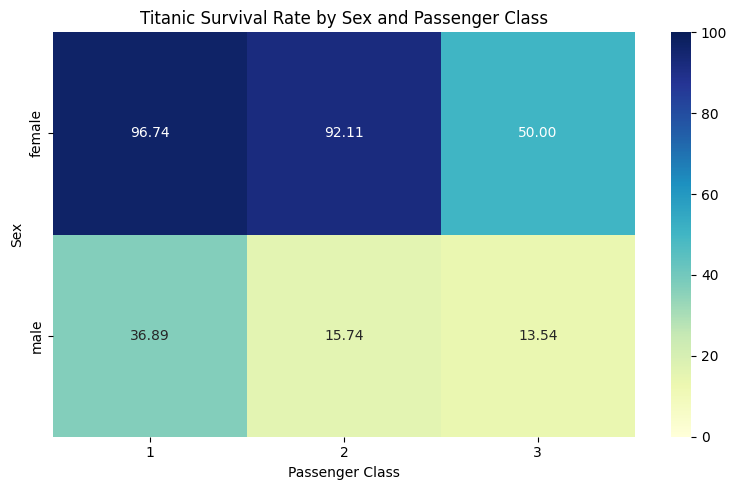

Multivariate heatmap saved successfully!


In [29]:
survival_heatmap = (
    df_clean
    .pivot_table(
        values="survived",
        index="sex",
        columns="pclass",
        aggfunc="mean"
    ) * 100
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    survival_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100
)

plt.title("Titanic Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")
plt.tight_layout()

plt.savefig(
    "analytics/charts/multivariate_survival_heatmap.png",
    dpi=300
)

plt.show()

print("Multivariate heatmap saved successfully!")

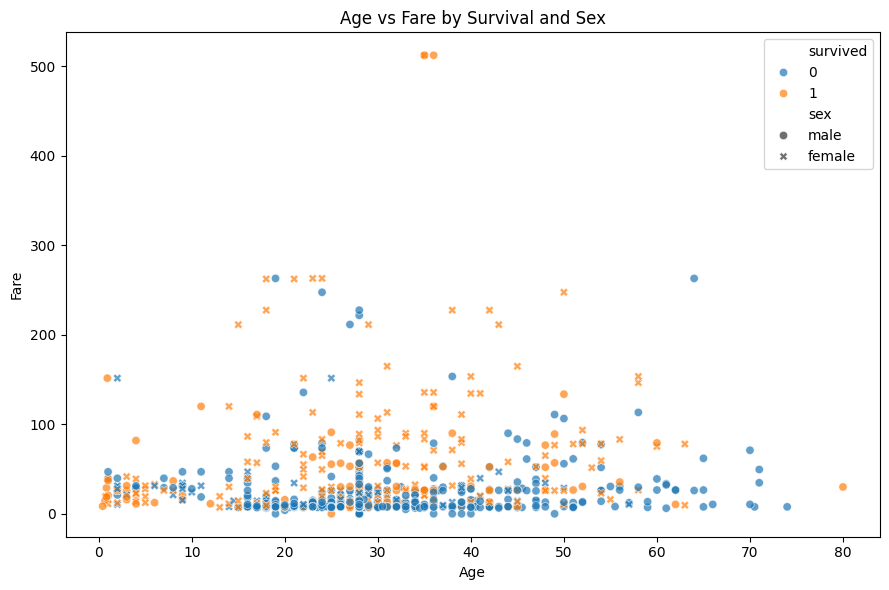

Age-Fare-Survival visualization created successfully!


In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()

plt.savefig(
    "analytics/charts/age_fare_survival.png",
    dpi=300
)

plt.show()

print("Age-Fare-Survival visualization created successfully!")

In [31]:
multivariate_summary.to_csv(
    "analytics/multivariate_summary.csv",
    index=False
)

survival_heatmap.to_csv(
    "analytics/survival_heatmap_values.csv"
)

print("Multivariate analysis results saved successfully!")

Multivariate analysis results saved successfully!


In [32]:
highest_survival_group = (
    multivariate_summary
    .loc[
        multivariate_summary["survival_rate_percent"].idxmax()
    ]
)

lowest_survival_group = (
    multivariate_summary
    .loc[
        multivariate_summary["survival_rate_percent"].idxmin()
    ]
)

print("=" * 70)
print("HIGHEST SURVIVAL GROUP")
print("=" * 70)

print(
    f"Sex: {highest_survival_group['sex']}"
)

print(
    f"Passenger Class: {int(highest_survival_group['pclass'])}"
)

print(
    f"Survival Rate: "
    f"{highest_survival_group['survival_rate_percent']:.2f}%"
)

print(
    f"Average Age: "
    f"{highest_survival_group['average_age']:.2f}"
)

print(
    f"Average Fare: "
    f"{highest_survival_group['average_fare']:.2f}"
)


print("\n" + "=" * 70)
print("LOWEST SURVIVAL GROUP")
print("=" * 70)

print(
    f"Sex: {lowest_survival_group['sex']}"
)

print(
    f"Passenger Class: {int(lowest_survival_group['pclass'])}"
)

print(
    f"Survival Rate: "
    f"{lowest_survival_group['survival_rate_percent']:.2f}%"
)

print(
    f"Average Age: "
    f"{lowest_survival_group['average_age']:.2f}"
)

print(
    f"Average Fare: "
    f"{lowest_survival_group['average_fare']:.2f}"
)

HIGHEST SURVIVAL GROUP
Sex: female
Passenger Class: 1
Survival Rate: 96.74%
Average Age: 33.63
Average Fare: 106.69

LOWEST SURVIVAL GROUP
Sex: male
Passenger Class: 3
Survival Rate: 13.54%
Average Age: 26.91
Average Fare: 12.66


## Multivariate Data Story

The multivariate analysis combines sex, passenger class, age, fare, and survival to understand how these factors interacted.

The highest survival rate was observed among female passengers in first class, with a survival rate of approximately 96.74%. This group had an average age of 33.63 years and an average fare of 106.69.

In contrast, the lowest survival rate was observed among male passengers in third class, with only 13.54% surviving. This group had an average age of 26.91 years and an average fare of 12.66.

The results suggest that sex and passenger class were important factors associated with survival. First-class female passengers had a substantially higher survival rate than third-class male passengers. The difference in average fare also reflects the economic distinction between these passenger groups.

Overall, the Titanic survival data tells a clear multivariate story: passengers' survival outcomes were strongly associated with both gender and passenger class, while age and fare provide additional context about the characteristics of these groups.

In [33]:
print("=" * 60)
print("MULTIVARIATE ANALYSIS COMPLETED")
print("=" * 60)

print("✓ Sex included")
print("✓ Passenger class included")
print("✓ Age included")
print("✓ Fare included")
print("✓ Survival included")
print("✓ Multivariate summary created")
print("✓ Survival heatmap created")
print("✓ Age-Fare-Survival visualization created")
print("✓ Interpretation added")

MULTIVARIATE ANALYSIS COMPLETED
✓ Sex included
✓ Passenger class included
✓ Age included
✓ Fare included
✓ Survival included
✓ Multivariate summary created
✓ Survival heatmap created
✓ Age-Fare-Survival visualization created
✓ Interpretation added


In [34]:
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

print("=" * 60)
print("NUMERICAL FEATURES BEFORE STANDARDIZATION")
print("=" * 60)

display(
    df_clean[numeric_features].describe().T[
        ["mean", "std", "min", "max"]
    ]
)

NUMERICAL FEATURES BEFORE STANDARDIZATION


,mean,std,min,max
age,29.315152,12.984932,0.42,80.0000
sibsp,0.524184,1.103705,0.00,8.0000
parch,0.382452,0.806761,0.00,6.0000
fare,32.096681,49.697504,0.00,512.3292
pclass,2.311586,0.834700,1.00,3.0000


In [35]:
from sklearn.preprocessing import StandardScaler

scaler_demo = StandardScaler()

scaled_values = scaler_demo.fit_transform(
    df_clean[numeric_features]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=numeric_features
)

print("=" * 60)
print("NUMERICAL FEATURES AFTER STANDARDIZATION")
print("=" * 60)

display(
    scaled_df.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

NUMERICAL FEATURES AFTER STANDARDIZATION


,mean,std,min,max
age,2.717486e-16,1.000563,-2.226536,3.905556
sibsp,-3.197043e-17,1.000563,-0.475199,6.777195
parch,-4.795564e-17,1.000563,-0.474326,6.967010
fare,1.398706e-16,1.000563,-0.646204,9.668551
pclass,-2.437745e-16,1.000563,-1.572211,0.825209


In [36]:
X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

print("=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

FEATURES AND TARGET
X shape: (889, 13)
y shape: (889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target percentages:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target distribution:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

TRAIN / TEST SPLIT
Training samples: 711
Testing samples : 178

Training target distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Testing target distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


In [38]:
print("=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print("Target column in X_train:", "survived" in X_train.columns)
print("Target column in X_test :", "survived" in X_test.columns)

print("\nResult:")
if "survived" not in X_train.columns and "survived" not in X_test.columns:
    print("✓ No target leakage detected.")
else:
    print("⚠ Target leakage detected.")

DATA LEAKAGE CHECK
Target column in X_train: False
Target column in X_test : False

Result:
✓ No target leakage detected.


In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone",
    "embark_town"
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("=" * 60)
print("PREPROCESSING PIPELINE CREATED")
print("=" * 60)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\n✓ Numerical: median imputation + StandardScaler")
print("✓ Categorical: most-frequent imputation + OneHotEncoder")
print("✓ Unknown categories handled safely")
print("✓ Preprocessing will be fitted only on training data")

PREPROCESSING PIPELINE CREATED
Numerical features:
['age', 'sibsp', 'parch', 'fare', 'pclass']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'alone', 'embark_town']

✓ Numerical: median imputation + StandardScaler
✓ Categorical: most-frequent imputation + OneHotEncoder
✓ Unknown categories handled safely
✓ Preprocessing will be fitted only on training data


In [4]:
import pandas as pd
import seaborn as sns


df = sns.load_dataset("titanic")

df_clean = df.copy()

df_clean = df_clean.drop(columns=["deck"])
df_clean = df_clean.dropna(
    subset=["embarked", "embark_town"]
)

age_median = df_clean["age"].median()

df_clean["age"] = df_clean["age"].fillna(age_median)

print("=" * 60)
print("CLEAN DATASET RESTORED")
print("=" * 60)

print("Shape:", df_clean.shape)
print("Remaining missing values:",
      df_clean.isnull().sum().sum())

print("\n✓ df_clean is ready")

CLEAN DATASET RESTORED
Shape: (889, 14)
Remaining missing values: 0

✓ df_clean is ready


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone",
    "embark_town"
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("✓ Preprocessing pipeline restored")

✓ Preprocessing pipeline restored


In [7]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Starting ML setup...")


df = sns.load_dataset("titanic")

df_clean = df.copy()

df_clean = df_clean.drop(columns=["deck"])

df_clean = df_clean.dropna(
    subset=["embarked", "embark_town"]
)
df_clean["age"] = df_clean["age"].fillna(
    df_clean["age"].median()
)

print("Clean dataset:", df_clean.shape)


X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone",
    "embark_town"
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("\n" + "=" * 60)
print("ML SETUP COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("\nOriginal X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

print("\nMissing values in processed training data:",
      pd.isna(X_train_processed).any())

print("Missing values in processed testing data:",
      pd.isna(X_test_processed).any())

print("\n✓ df_clean restored")
print("✓ X_train restored")
print("✓ X_test restored")
print("✓ y_train restored")
print("✓ y_test restored")
print("✓ Preprocessor restored")
print("✓ Preprocessor fitted only on X_train")
print("✓ X_test transformed without fitting")

Starting ML setup...
Clean dataset: (889, 14)
X_train: (711, 13)
X_test : (178, 13)
y_train: (711,)
y_test : (178,)

ML SETUP COMPLETED SUCCESSFULLY
Original X_train: (711, 13)
Processed X_train: (711, 23)

Original X_test: (178, 13)
Processed X_test: (178, 23)

Missing values in processed training data: False
Missing values in processed testing data: False

✓ df_clean restored
✓ X_train restored
✓ X_test restored
✓ y_train restored
✓ y_test restored
✓ Preprocessor restored
✓ Preprocessor fitted only on X_train
✓ X_test transformed without fitting


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402


LOGISTIC REGRESSION RESULTS
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402

CONFUSION MATRIX
[[98 12]
 [21 47]]


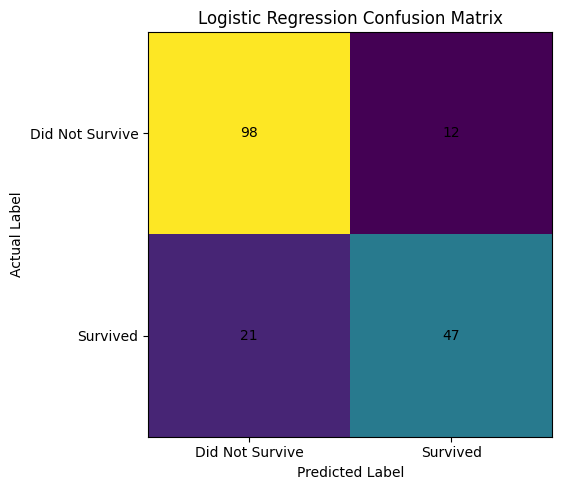


✓ Logistic Regression completed
✓ Confusion matrix saved
✓ Results saved


In [12]:
import os
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

os.makedirs("analytics/charts", exist_ok=True)

y_pred_logistic = logistic_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, zero_division=0)
recall = recall_score(y_test, y_pred_logistic, zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

cm = confusion_matrix(y_test, y_pred_logistic)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_yticklabels(["Did Not Survive", "Survived"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "analytics/charts/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1]
})

results.to_csv(
    "analytics/logistic_regression_results.csv",
    index=False
)

print("\n✓ Logistic Regression completed")
print("✓ Confusion matrix saved")
print("✓ Results saved")

In [13]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_pipeline.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

print("=" * 60)
print("DECISION TREE RESULTS")
print("=" * 60)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

DECISION TREE RESULTS
Accuracy : 0.7921
Precision: 0.8163
Recall   : 0.5882
F1 Score : 0.6838


DECISION TREE CONFUSION MATRIX
[[101   9]
 [ 28  40]]


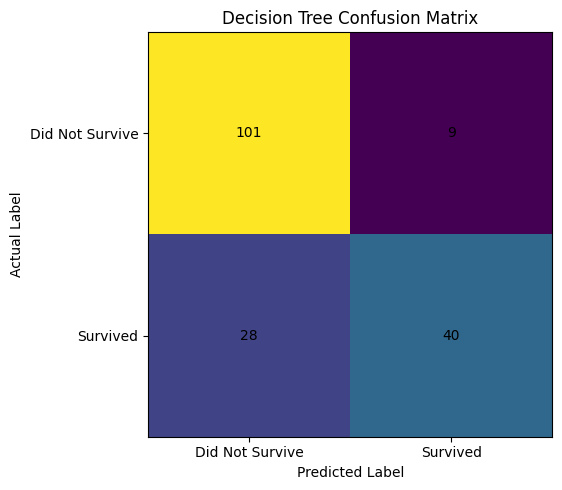

Decision Tree confusion matrix saved successfully!


In [14]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "analytics/charts",
    exist_ok=True
)

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("=" * 60)
print("DECISION TREE CONFUSION MATRIX")
print("=" * 60)

print(cm_tree)

fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_tree)

ax.set_title("Decision Tree Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Did Not Survive", "Survived"]
)

ax.set_yticklabels(
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm_tree[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "analytics/charts/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Decision Tree confusion matrix saved successfully!")

In [15]:
tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [tree_accuracy],
    "Precision": [tree_precision],
    "Recall": [tree_recall],
    "F1_Score": [tree_f1]
})

tree_results.to_csv(
    "analytics/decision_tree_results.csv",
    index=False
)

display(tree_results)

print("Decision Tree results saved successfully!")

,Model,Accuracy,Precision,Recall,F1_Score
0,Decision Tree,0.792135,0.816327,0.588235,0.683761


Decision Tree results saved successfully!


In [16]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                max_depth=8
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_pipeline.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

RANDOM FOREST RESULTS
Accuracy : 0.7921
Precision: 0.7719
Recall   : 0.6471
F1 Score : 0.7040


RANDOM FOREST CONFUSION MATRIX
[[97 13]
 [24 44]]


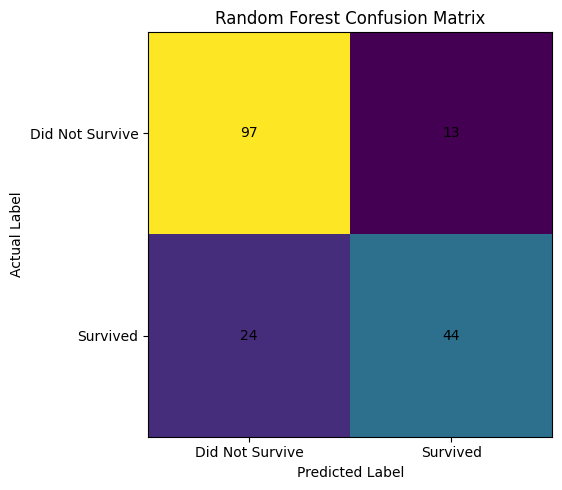

Random Forest confusion matrix saved successfully!


In [17]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "analytics/charts",
    exist_ok=True
)

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("=" * 60)
print("RANDOM FOREST CONFUSION MATRIX")
print("=" * 60)

print(cm_rf)

fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_rf)

ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Did Not Survive", "Survived"]
)

ax.set_yticklabels(
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm_rf[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "analytics/charts/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Random Forest confusion matrix saved successfully!")

In [ ]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1_Score": [rf_f1]
})

rf_results.to_csv(
    "analytics/random_forest_results.csv",
    index=False
)

display(rf_results)

print("Random Forest results saved successfully!")

In [18]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1_Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ]
})

model_comparison = model_comparison.sort_values(
    "F1_Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 70)

display(
    model_comparison.round(4)
)

model_comparison.to_csv(
    "analytics/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.8146,0.7966,0.6912,0.7402
1,Random Forest,0.7921,0.7719,0.6471,0.7040
2,Decision Tree,0.7921,0.8163,0.5882,0.6838


Model comparison saved successfully!


In [19]:
best_model = model_comparison.iloc[0]

print("=" * 60)
print("BEST CLASSIFICATION MODEL")
print("=" * 60)

print("Model:", best_model["Model"])
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall   : {best_model['Recall']:.4f}")
print(f"F1 Score : {best_model['F1_Score']:.4f}")

BEST CLASSIFICATION MODEL
Model: Logistic Regression
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402


## Classification Model Comparison

Three classification models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

Logistic Regression achieved the best overall performance, with an accuracy of 81.46% and an F1 score of 0.7402. It also achieved the highest recall of 0.6912 among the three models.

Random Forest achieved an accuracy of 79.21% and an F1 score of 0.7040. Although it performed reasonably well, it did not outperform Logistic Regression on the selected evaluation metrics.

Decision Tree also achieved an accuracy of 79.21%, but its F1 score was lower at 0.6838. It had the highest precision of 0.8163, but its recall was only 0.5882.

Based on the F1 score, Logistic Regression was selected as the best-performing classification model for this dataset.

In [20]:
class_counts = y.value_counts().sort_index()

class_percentages = (
    y.value_counts(normalize=True)
    .sort_index() * 100
)

class_balance = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

display(class_balance)

print("\nSurvival class distribution:")
for _, row in class_balance.iterrows():
    label = "Did Not Survive" if row["Class"] == 0 else "Survived"
    print(
        f"{label}: {int(row['Count'])} "
        f"({row['Percentage']:.2f}%)"
    )

CLASS DISTRIBUTION


,Class,Count,Percentage
0,0,549,61.754781
1,1,340,38.245219



Survival class distribution:
Did Not Survive: 549 (61.75%)
Survived: 340 (38.25%)


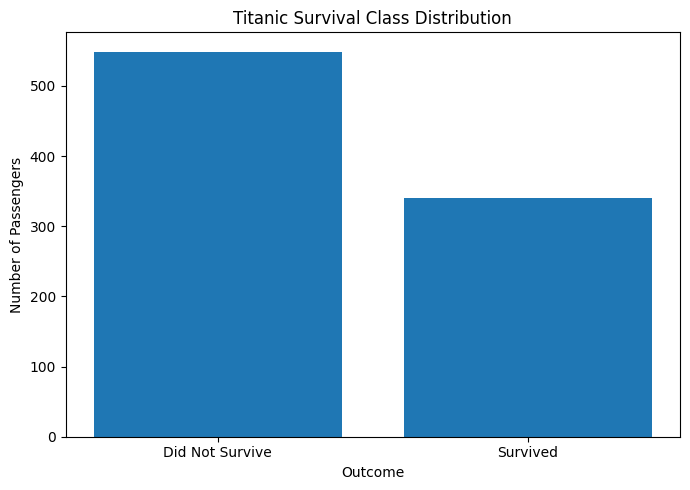

Class distribution chart saved successfully!


In [21]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "analytics/charts",
    exist_ok=True
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Did Not Survive", "Survived"],
    class_counts.values
)

plt.title("Titanic Survival Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Passengers")

plt.tight_layout()

plt.savefig(
    "analytics/charts/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class distribution chart saved successfully!")

In [22]:
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_logistic_pipeline.fit(
    X_train,
    y_train
)

y_pred_balanced = balanced_logistic_pipeline.predict(
    X_test
)

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

balanced_precision = precision_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

print("=" * 60)
print("BALANCED LOGISTIC REGRESSION")
print("=" * 60)

print(f"Accuracy : {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall   : {balanced_recall:.4f}")
print(f"F1 Score : {balanced_f1:.4f}")

BALANCED LOGISTIC REGRESSION
Accuracy : 0.8315
Precision: 0.7794
Recall   : 0.7794
F1 Score : 0.7794


In [23]:
imbalance_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        logistic_accuracy,
        balanced_accuracy
    ],
    "Precision": [
        logistic_precision,
        balanced_precision
    ],
    "Recall": [
        logistic_recall,
        balanced_recall
    ],
    "F1_Score": [
        logistic_f1,
        balanced_f1
    ]
})

print("=" * 70)
print("ORIGINAL VS BALANCED LOGISTIC REGRESSION")
print("=" * 70)

display(
    imbalance_comparison.round(4)
)

imbalance_comparison.to_csv(
    "analytics/imbalance_comparison.csv",
    index=False
)

print("Imbalance comparison saved successfully!")

ORIGINAL VS BALANCED LOGISTIC REGRESSION


,Model,Accuracy,Precision,Recall,F1_Score
0,Original Logistic Regression,0.8146,0.7966,0.6912,0.7402
1,Balanced Logistic Regression,0.8315,0.7794,0.7794,0.7794


Imbalance comparison saved successfully!


## Class Imbalance Analysis

The target variable `survived` was examined for class imbalance. Since the Titanic dataset contains fewer survivors than non-survivors, class imbalance can affect model performance.

To address this, a second Logistic Regression model was trained using `class_weight="balanced"`.

The original Logistic Regression achieved an accuracy of 81.46%, recall of 69.12%, and F1 score of 74.02%.

After applying class weighting, Balanced Logistic Regression achieved an accuracy of 83.15%, recall of 77.94%, and F1 score of 77.94%. Precision decreased slightly from 79.66% to 77.94%.

The balanced model therefore provided better overall performance based on accuracy, recall, and F1 score. In particular, the improvement in recall indicates that the balanced model was better at identifying passengers who actually survived.

Based on these results, Balanced Logistic Regression is preferred over the original Logistic Regression for the next stage of model development.

In [24]:
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear", "lbfgs"]
}


grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("=" * 60)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 60)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING RESULTS
Best Parameters:
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.7654


In [25]:
best_model_pipeline = grid_search.best_estimator_

y_pred_tuned = best_model_pipeline.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

print("=" * 60)
print("TUNED LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")

TUNED LOGISTIC REGRESSION RESULTS
Accuracy : 0.8146
Precision: 0.7966
Recall   : 0.6912
F1 Score : 0.7402


In [26]:
print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")

BEST HYPERPARAMETERS
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.7654


In [27]:
final_model = balanced_logistic_pipeline

y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_pred_final, zero_division=0)

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print("Final Model: Balanced Logistic Regression")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

FINAL MODEL RESULTS
Final Model: Balanced Logistic Regression
Accuracy : 0.8315
Precision: 0.7794
Recall   : 0.7794
F1 Score : 0.7794


FINAL MODEL CONFUSION MATRIX
[[95 15]
 [15 53]]


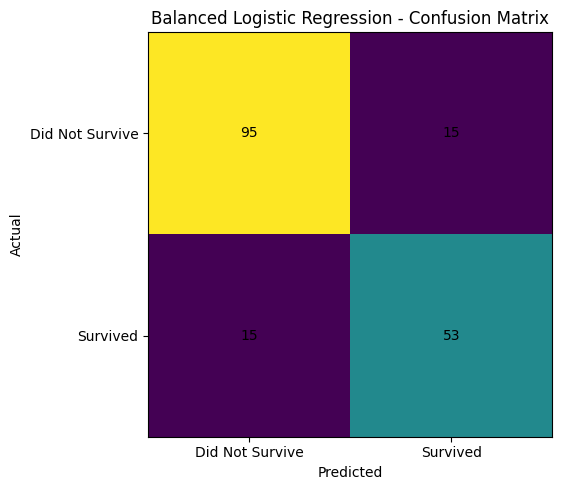

Final confusion matrix saved!


In [28]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

os.makedirs("analytics/charts", exist_ok=True)

cm_final = confusion_matrix(y_test, y_pred_final)

print("=" * 60)
print("FINAL MODEL CONFUSION MATRIX")
print("=" * 60)

print(cm_final)

fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_final)

ax.set_title("Balanced Logistic Regression - Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_yticklabels(["Did Not Survive", "Survived"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm_final[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "analytics/charts/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final confusion matrix saved!")

In [29]:
import joblib
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["Balanced Logistic Regression"],
    "Accuracy": [final_accuracy],
    "Precision": [final_precision],
    "Recall": [final_recall],
    "F1_Score": [final_f1]
})

final_results.to_csv(
    "analytics/final_model_results.csv",
    index=False
)

joblib.dump(
    final_model,
    "analytics/final_model.pkl"
)

final_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final
})

final_predictions.to_csv(
    "analytics/final_predictions.csv",
    index=False
)

display(final_results.round(4))

print("✓ Final model results saved")
print("✓ Final model saved")
print("✓ Final predictions saved")

,Model,Accuracy,Precision,Recall,F1_Score
0,Balanced Logistic Regression,0.8315,0.7794,0.7794,0.7794


✓ Final model results saved
✓ Final model saved
✓ Final predictions saved


In [30]:
complete_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        balanced_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        balanced_precision,
        tuned_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        balanced_recall,
        tuned_recall
    ],
    "F1_Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        balanced_f1,
        tuned_f1
    ]
})

complete_comparison = complete_comparison.sort_values(
    "F1_Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("COMPLETE MODEL COMPARISON")
print("=" * 70)

display(complete_comparison.round(4))

complete_comparison.to_csv(
    "analytics/complete_model_comparison.csv",
    index=False
)

print("✓ Complete comparison saved")

COMPLETE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score
0,Balanced Logistic Regression,0.8315,0.7794,0.7794,0.7794
1,Logistic Regression,0.8146,0.7966,0.6912,0.7402
2,Tuned Logistic Regression,0.8146,0.7966,0.6912,0.7402
3,Random Forest,0.7921,0.7719,0.6471,0.7040
4,Decision Tree,0.7921,0.8163,0.5882,0.6838


✓ Complete comparison saved


In [31]:
best_row = complete_comparison.iloc[0]

print("=" * 70)
print("FINAL MACHINE LEARNING SUMMARY")
print("=" * 70)

print(f"Best Model: {best_row['Model']}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1 Score  : {best_row['F1_Score']:.4f}")

print("\nGridSearchCV Best Parameters:")
print(grid_search.best_params_)

print(f"\nGridSearchCV Best CV F1: {grid_search.best_score_:.4f}")

print("\n✓ Machine Learning section completed")

FINAL MACHINE LEARNING SUMMARY
Best Model: Balanced Logistic Regression
Accuracy  : 0.8315
Precision : 0.7794
Recall    : 0.7794
F1 Score  : 0.7794

GridSearchCV Best Parameters:
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}

GridSearchCV Best CV F1: 0.7654

✓ Machine Learning section completed


In [32]:
import os

print("=" * 70)
print("FINAL OUTPUT FILE CHECK")
print("=" * 70)

required_files = [
    "analytics/final_model_results.csv",
    "analytics/final_model.pkl",
    "analytics/final_predictions.csv",
    "analytics/complete_model_comparison.csv",
    "analytics/imbalance_comparison.csv",
    "analytics/logistic_regression_results.csv",
    "analytics/decision_tree_results.csv",
    "analytics/random_forest_results.csv",
    "analytics/charts/final_confusion_matrix.png",
    "analytics/charts/logistic_confusion_matrix.png",
    "analytics/charts/decision_tree_confusion_matrix.png",
    "analytics/charts/random_forest_confusion_matrix.png",
    "analytics/charts/class_distribution.png"
]

for file in required_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

print("\nFile check completed.")

FINAL OUTPUT FILE CHECK
✓ analytics/final_model_results.csv
✓ analytics/final_model.pkl
✓ analytics/final_predictions.csv
✓ analytics/complete_model_comparison.csv
✓ analytics/imbalance_comparison.csv
✓ analytics/logistic_regression_results.csv
✓ analytics/decision_tree_results.csv
✗ MISSING: analytics/random_forest_results.csv
✓ analytics/charts/final_confusion_matrix.png
✓ analytics/charts/logistic_confusion_matrix.png
✓ analytics/charts/decision_tree_confusion_matrix.png
✓ analytics/charts/random_forest_confusion_matrix.png
✓ analytics/charts/class_distribution.png

File check completed.


In [33]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1_Score": [rf_f1]
})

rf_results.to_csv(
    "analytics/random_forest_results.csv",
    index=False
)

display(rf_results.round(4))

print("✓ Random Forest results saved successfully!")

,Model,Accuracy,Precision,Recall,F1_Score
0,Random Forest,0.7921,0.7719,0.6471,0.704


✓ Random Forest results saved successfully!


In [34]:
import os

print("=" * 70)
print("FINAL OUTPUT FILE CHECK")
print("=" * 70)

required_files = [
    "analytics/final_model_results.csv",
    "analytics/final_model.pkl",
    "analytics/final_predictions.csv",
    "analytics/complete_model_comparison.csv",
    "analytics/imbalance_comparison.csv",
    "analytics/logistic_regression_results.csv",
    "analytics/decision_tree_results.csv",
    "analytics/random_forest_results.csv",
    "analytics/charts/final_confusion_matrix.png",
    "analytics/charts/logistic_confusion_matrix.png",
    "analytics/charts/decision_tree_confusion_matrix.png",
    "analytics/charts/random_forest_confusion_matrix.png",
    "analytics/charts/class_distribution.png"
]

for file in required_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

print("\nFile check completed.")

FINAL OUTPUT FILE CHECK
✓ analytics/final_model_results.csv
✓ analytics/final_model.pkl
✓ analytics/final_predictions.csv
✓ analytics/complete_model_comparison.csv
✓ analytics/imbalance_comparison.csv
✓ analytics/logistic_regression_results.csv
✓ analytics/decision_tree_results.csv
✓ analytics/random_forest_results.csv
✓ analytics/charts/final_confusion_matrix.png
✓ analytics/charts/logistic_confusion_matrix.png
✓ analytics/charts/decision_tree_confusion_matrix.png
✓ analytics/charts/random_forest_confusion_matrix.png
✓ analytics/charts/class_distribution.png

File check completed.
